In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

df1 = pd.read_csv("/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/group-housed/behaviour_detection.csv")
df1["condition"] = 'GH'

df2 = pd.read_csv("/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/socially-isolated/behaviour_detection.csv")
df2["condition"] = 'SI'


df = pd.concat([df1, df2], ignore_index=True)

PALETTE = {
    "GH": 'steelblue',     
    "SI": 'darkorange',}

HUE_ORDER = ["GH", "SI"]

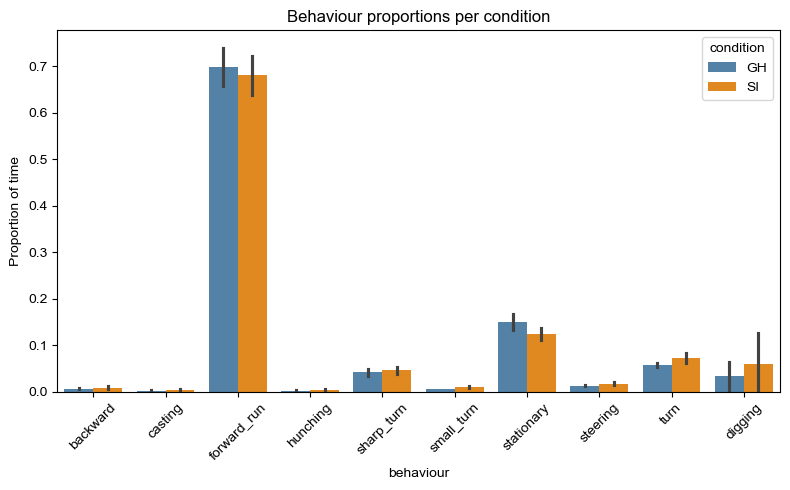

In [38]:
# total frames per video
total_frames = (
    df.groupby(["file"])
    .size()
    .reset_index(name="total_frames")
)

# frames per behaviour per video
behaviour_frames = (
    df.groupby(["file", "condition", "behaviour"])
    .size()
    .reset_index(name="n_frames")
)

# merge + compute proportion
behaviour_prop = behaviour_frames.merge(total_frames, on="file")
behaviour_prop["proportion"] = behaviour_prop["n_frames"] / behaviour_prop["total_frames"]


plt.figure(figsize=(8,5))

sns.barplot(
    data=behaviour_prop,
    x="behaviour",
    y="proportion",
    hue="condition",
    errorbar="sd", palette=PALETTE, hue_order=HUE_ORDER
)

plt.ylim(0,None)
plt.xticks(rotation=45)
plt.ylabel("Proportion of time")
plt.title("Behaviour proportions per condition")

plt.tight_layout()
plt.show()

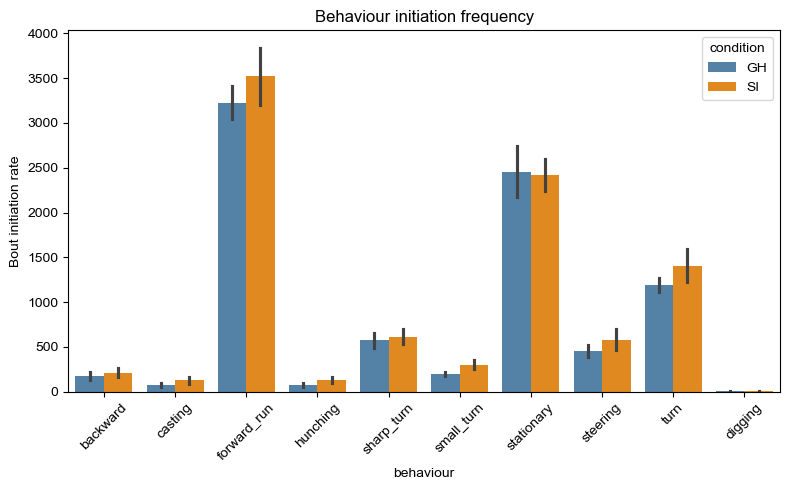

In [39]:
df = df.sort_values(["file", "track_id", "frame"]).copy()

df["prev_behaviour"] = df.groupby(["file", "track_id"])["behaviour"].shift()

df["is_initiation"] = df["behaviour"] != df["prev_behaviour"]

bout_counts = (
    df[df["is_initiation"]]
    .groupby(["file", "condition", "behaviour"])
    .size()
    .reset_index(name="n_bouts")
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=bout_counts,
    x="behaviour",
    y="n_bouts",
    hue="condition",
    errorbar="sd", palette=PALETTE, hue_order=HUE_ORDER
)

plt.xticks(rotation=45)
plt.ylabel("Bout initiation rate")
plt.title("Behaviour initiation frequency")

plt.tight_layout()
plt.show()

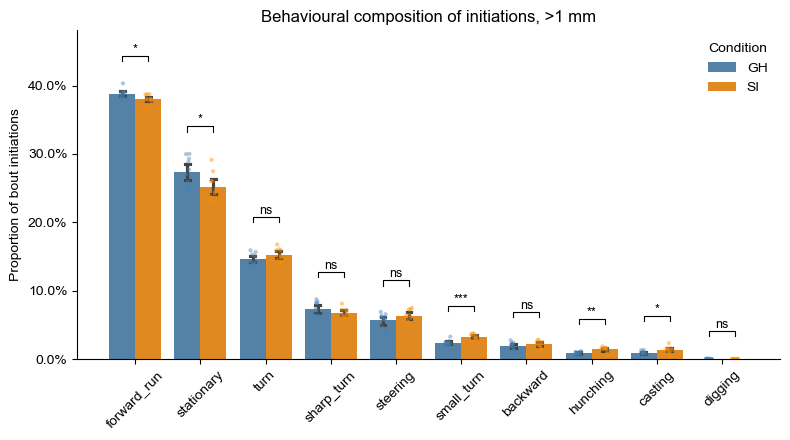

,condition,behaviour,mean_proportion,sem_proportion,mean_n_bouts,n_recordings,p_value,significance
0,GH,backward,0.019279,0.001731,143.1,10,0.161972,ns
1,GH,casting,0.009257,0.000918,68.9,10,0.011330,*
2,GH,digging,0.000342,0.000137,2.6,10,0.334317,ns
3,GH,forward_run,0.387833,0.002100,2897.4,10,0.014019,*
4,GH,hunching,0.008609,0.000715,64.3,10,0.003611,**
5,GH,sharp_turn,0.073444,0.003089,549.9,10,0.185877,ns
6,GH,small_turn,0.024330,0.001071,181.4,10,0.000769,***
7,GH,stationary,0.274043,0.006507,2048.3,10,0.031209,*
8,GH,steering,0.056684,0.003149,423.3,10,0.241322,ns
9,GH,turn,0.146178,0.002631,1092.2,10,0.121225,ns


In [40]:
# Bout initiation types when larvae are >1 mm from their nearest neighbour

import matplotlib.ticker as mtick
from scipy.stats import mannwhitneyu

# keep only frames with a measured neighbour distance >1 mm
df_far = df[
    df["closest_node_node_distance"].notna()
    & (df["closest_node_node_distance"] > 1)
].copy()

# an initiation is a change in behaviour within a file/track
df_far = df_far.sort_values(["file", "track_id", "frame"])
df_far["prev_behaviour"] = df_far.groupby(["file", "track_id"])["behaviour"].shift()
df_far = df_far[df_far["prev_behaviour"].notna()]
df_far["is_initiation"] = df_far["behaviour"] != df_far["prev_behaviour"]

# count initiations per recording and behaviour
bout_counts = (
    df_far[df_far["is_initiation"]]
    .groupby(["file", "condition", "behaviour"])
    .size()
    .reset_index(name="n_bouts")
)

# add zeros where a recording had no initiations for a behaviour
behaviour_order = (
    bout_counts.groupby("behaviour")["n_bouts"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

recordings = bout_counts[["file", "condition"]].drop_duplicates().copy()
behaviours = pd.DataFrame({"behaviour": behaviour_order})
recordings["_key"] = 1
behaviours["_key"] = 1

bout_counts = (
    recordings.merge(behaviours, on="_key")
    .drop(columns="_key")
    .merge(bout_counts, on=["file", "condition", "behaviour"], how="left")
)
bout_counts["n_bouts"] = bout_counts["n_bouts"].fillna(0)

# calculate each behaviour as a proportion of all initiations in that recording
bout_counts["total_bouts"] = bout_counts.groupby(["file", "condition"])["n_bouts"].transform("sum")
bout_counts = bout_counts[bout_counts["total_bouts"] > 0].copy()
bout_counts["bout_proportion"] = bout_counts["n_bouts"] / bout_counts["total_bouts"]

condition_order = [c for c in HUE_ORDER if c in bout_counts["condition"].unique()]
if len(condition_order) == 0:
    condition_order = sorted(bout_counts["condition"].dropna().unique())

palette = PALETTE

def p_to_stars(p_value):
    if pd.isna(p_value):
        return "n/a"
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "ns"

# Mann-Whitney U per behaviour, comparing per-recording proportions
stats_rows = []
if len(condition_order) == 2:
    condition_a, condition_b = condition_order
    for behaviour in behaviour_order:
        values_a = bout_counts.loc[
            (bout_counts["condition"] == condition_a)
            & (bout_counts["behaviour"] == behaviour),
            "bout_proportion",
        ]
        values_b = bout_counts.loc[
            (bout_counts["condition"] == condition_b)
            & (bout_counts["behaviour"] == behaviour),
            "bout_proportion",
        ]

        if len(values_a) > 0 and len(values_b) > 0:
            _, p_value = mannwhitneyu(values_a, values_b, alternative="two-sided")
        else:
            p_value = np.nan

        stats_rows.append({
            "behaviour": behaviour,
            f"n_{condition_a}": len(values_a),
            f"n_{condition_b}": len(values_b),
            "p_value": p_value,
            "significance": p_to_stars(p_value),
        })

stats_table = pd.DataFrame(stats_rows)

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(
    data=bout_counts,
    x="behaviour",
    y="bout_proportion",
    hue="condition",
    order=behaviour_order,
    hue_order=condition_order,
    palette=palette,
    errorbar=("ci", 95),
    capsize=0.15,
)
sns.stripplot(
    data=bout_counts,
    x="behaviour",
    y="bout_proportion",
    hue="condition",
    order=behaviour_order,
    hue_order=condition_order,
    palette=palette,
    dodge=True,
    alpha=0.45,
    size=3,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Proportion of bout initiations")
ax.set_title("Behavioural composition of initiations, >1 mm")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis="x", rotation=45)

# add significance brackets
if len(condition_order) == 2 and not stats_table.empty:
    y_max = bout_counts["bout_proportion"].max()
    y_step = max(y_max * 0.08, 0.03)
    bracket_height = y_step * 0.25
    ax.set_ylim(0, y_max + y_step * 2.4)

    for x, behaviour in enumerate(behaviour_order):
        y = bout_counts.loc[bout_counts["behaviour"] == behaviour, "bout_proportion"].max() + y_step
        label = stats_table.loc[stats_table["behaviour"] == behaviour, "significance"].iloc[0]
        x1, x2 = x - 0.2, x + 0.2
        ax.plot([x1, x1, x2, x2], [y, y + bracket_height, y + bracket_height, y], color="black", lw=0.8)
        ax.text(x, y + bracket_height, label, ha="center", va="bottom", fontsize=9)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(condition_order)], labels[:len(condition_order)], title="Condition", frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

summary_table = (
    bout_counts.groupby(["condition", "behaviour"], as_index=False)
    .agg(
        mean_proportion=("bout_proportion", "mean"),
        sem_proportion=("bout_proportion", "sem"),
        mean_n_bouts=("n_bouts", "mean"),
        n_recordings=("file", "nunique"),
    )
)

if not stats_table.empty:
    summary_table = summary_table.merge(
        stats_table[["behaviour", "p_value", "significance"]],
        on="behaviour",
        how="left",
    )

display(summary_table)


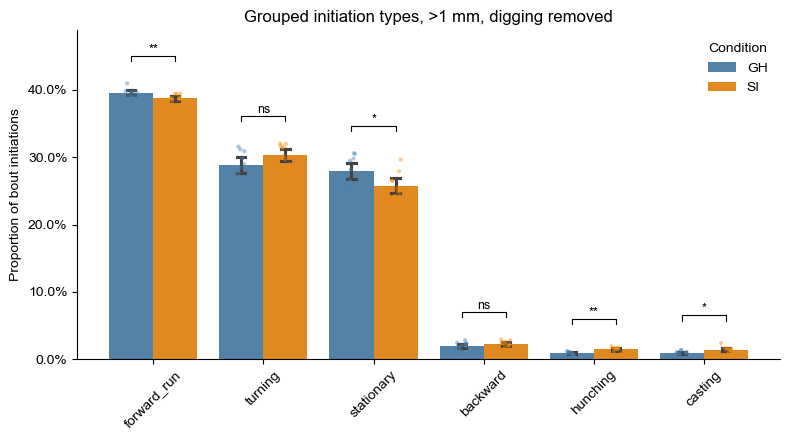

,condition,behaviour_grouped,mean_proportion,sem_proportion,mean_n_bouts,n_recordings,p_value,significance
0,GH,backward,0.019639,0.001764,143.1,10,0.161972,ns
1,GH,casting,0.009430,0.000933,68.9,10,0.011330,*
2,GH,forward_run,0.395020,0.001951,2897.1,10,0.009108,**
3,GH,hunching,0.008770,0.000728,64.3,10,0.003611,**
4,GH,stationary,0.279142,0.006615,2048.2,10,0.025748,*
5,GH,turning,0.287999,0.006339,2112.7,10,0.088973,ns
6,SI,backward,0.022659,0.001458,195.5,10,0.161972,ns
7,SI,casting,0.014348,0.001388,123.1,10,0.011330,*
8,SI,forward_run,0.387759,0.001899,3348.7,10,0.009108,**
9,SI,hunching,0.014888,0.001047,129.2,10,0.003611,**


In [41]:
# Bout initiation types >1 mm, with turning behaviours grouped and digging removed

import matplotlib.ticker as mtick
from scipy.stats import mannwhitneyu

turning_behaviours = ["turn", "sharp_turn", "small_turn", "steering"]

# keep only frames with a measured neighbour distance >1 mm
df_far = df[
    df["closest_node_node_distance"].notna()
    & (df["closest_node_node_distance"] > 1)
].copy()

# group turning behaviours and remove digging
df_far["behaviour_grouped"] = df_far["behaviour"].replace(
    {behaviour: "turning" for behaviour in turning_behaviours}
)
df_far = df_far[df_far["behaviour_grouped"] != "digging"].copy()

# an initiation is a change in grouped behaviour within a file/track
df_far = df_far.sort_values(["file", "track_id", "frame"])
df_far["prev_behaviour"] = df_far.groupby(["file", "track_id"])["behaviour_grouped"].shift()
df_far = df_far[df_far["prev_behaviour"].notna()]
df_far["is_initiation"] = df_far["behaviour_grouped"] != df_far["prev_behaviour"]

# count initiations per recording and grouped behaviour
bout_counts = (
    df_far[df_far["is_initiation"]]
    .groupby(["file", "condition", "behaviour_grouped"])
    .size()
    .reset_index(name="n_bouts")
)

behaviour_order = (
    bout_counts.groupby("behaviour_grouped")["n_bouts"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

# add zeros where a recording had no initiations for a behaviour
recordings = bout_counts[["file", "condition"]].drop_duplicates().copy()
behaviours = pd.DataFrame({"behaviour_grouped": behaviour_order})
recordings["_key"] = 1
behaviours["_key"] = 1

bout_counts = (
    recordings.merge(behaviours, on="_key")
    .drop(columns="_key")
    .merge(bout_counts, on=["file", "condition", "behaviour_grouped"], how="left")
)
bout_counts["n_bouts"] = bout_counts["n_bouts"].fillna(0)

# calculate each grouped behaviour as a proportion of all initiations in that recording
bout_counts["total_bouts"] = bout_counts.groupby(["file", "condition"])["n_bouts"].transform("sum")
bout_counts = bout_counts[bout_counts["total_bouts"] > 0].copy()
bout_counts["bout_proportion"] = bout_counts["n_bouts"] / bout_counts["total_bouts"]

condition_order = [c for c in HUE_ORDER if c in bout_counts["condition"].unique()]
if len(condition_order) == 0:
    condition_order = sorted(bout_counts["condition"].dropna().unique())

palette = PALETTE

def p_to_stars(p_value):
    if pd.isna(p_value):
        return "n/a"
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "ns"

# Mann-Whitney U per grouped behaviour, comparing per-recording proportions
stats_rows = []
if len(condition_order) == 2:
    condition_a, condition_b = condition_order
    for behaviour in behaviour_order:
        values_a = bout_counts.loc[
            (bout_counts["condition"] == condition_a)
            & (bout_counts["behaviour_grouped"] == behaviour),
            "bout_proportion",
        ]
        values_b = bout_counts.loc[
            (bout_counts["condition"] == condition_b)
            & (bout_counts["behaviour_grouped"] == behaviour),
            "bout_proportion",
        ]

        if len(values_a) > 0 and len(values_b) > 0:
            _, p_value = mannwhitneyu(values_a, values_b, alternative="two-sided")
        else:
            p_value = np.nan

        stats_rows.append({
            "behaviour_grouped": behaviour,
            f"n_{condition_a}": len(values_a),
            f"n_{condition_b}": len(values_b),
            "p_value": p_value,
            "significance": p_to_stars(p_value),
        })

stats_table = pd.DataFrame(stats_rows)

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(
    data=bout_counts,
    x="behaviour_grouped",
    y="bout_proportion",
    hue="condition",
    order=behaviour_order,
    hue_order=condition_order,
    palette=palette,
    errorbar=("ci", 95),
    capsize=0.15,
)
sns.stripplot(
    data=bout_counts,
    x="behaviour_grouped",
    y="bout_proportion",
    hue="condition",
    order=behaviour_order,
    hue_order=condition_order,
    palette=palette,
    dodge=True,
    alpha=0.45,
    size=3,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Proportion of bout initiations")
ax.set_title("Grouped initiation types, >1 mm, digging removed")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis="x", rotation=45)

# add significance brackets
if len(condition_order) == 2 and not stats_table.empty:
    y_max = bout_counts["bout_proportion"].max()
    y_step = max(y_max * 0.08, 0.03)
    bracket_height = y_step * 0.25
    ax.set_ylim(0, y_max + y_step * 2.4)

    for x, behaviour in enumerate(behaviour_order):
        y = bout_counts.loc[bout_counts["behaviour_grouped"] == behaviour, "bout_proportion"].max() + y_step
        label = stats_table.loc[stats_table["behaviour_grouped"] == behaviour, "significance"].iloc[0]
        x1, x2 = x - 0.2, x + 0.2
        ax.plot([x1, x1, x2, x2], [y, y + bracket_height, y + bracket_height, y], color="black", lw=0.8)
        ax.text(x, y + bracket_height, label, ha="center", va="bottom", fontsize=9)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(condition_order)], labels[:len(condition_order)], title="Condition", frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

summary_table = (
    bout_counts.groupby(["condition", "behaviour_grouped"], as_index=False)
    .agg(
        mean_proportion=("bout_proportion", "mean"),
        sem_proportion=("bout_proportion", "sem"),
        mean_n_bouts=("n_bouts", "mean"),
        n_recordings=("file", "nunique"),
    )
)

if not stats_table.empty:
    summary_table = summary_table.merge(
        stats_table[["behaviour_grouped", "p_value", "significance"]],
        on="behaviour_grouped",
        how="left",
    )

display(summary_table)


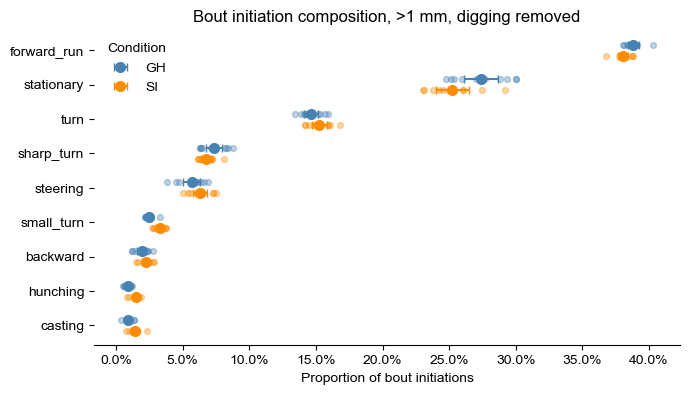

,condition,behaviour,mean_proportion,ci_low,ci_high,n_recordings
0,GH,backward,0.019286,0.015894,0.022679,10
1,GH,casting,0.009260,0.007462,0.011059,10
2,GH,forward_run,0.387947,0.383818,0.392075,10
3,GH,hunching,0.008612,0.007211,0.010013,10
4,GH,sharp_turn,0.073472,0.067423,0.079520,10
5,GH,small_turn,0.024339,0.022241,0.026437,10
6,GH,stationary,0.274143,0.261351,0.286935,10
7,GH,steering,0.056706,0.050532,0.062881,10
8,GH,turn,0.146235,0.141095,0.151374,10
9,SI,backward,0.022244,0.019434,0.025054,10


In [42]:
# Horizontal replicate plot of bout initiation proportions, digging removed

import matplotlib.ticker as mtick

# keep only frames with a measured neighbour distance >1 mm and remove digging
df_far = df[
    df["closest_node_node_distance"].notna()
    & (df["closest_node_node_distance"] > 1)
    & (df["behaviour"] != "digging")
].copy()

# an initiation is a change in behaviour within a file/track
df_far = df_far.sort_values(["file", "track_id", "frame"])
df_far["prev_behaviour"] = df_far.groupby(["file", "track_id"])["behaviour"].shift()
df_far = df_far[df_far["prev_behaviour"].notna()]
df_far["is_initiation"] = df_far["behaviour"] != df_far["prev_behaviour"]

# count initiations per recording and behaviour
bout_counts = (
    df_far[df_far["is_initiation"]]
    .groupby(["file", "condition", "behaviour"])
    .size()
    .reset_index(name="n_bouts")
)

# add zeros where a recording had no initiations for a behaviour
behaviour_order = (
    bout_counts.groupby("behaviour")["n_bouts"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

recordings = bout_counts[["file", "condition"]].drop_duplicates().copy()
behaviours = pd.DataFrame({"behaviour": behaviour_order})
recordings["_key"] = 1
behaviours["_key"] = 1

bout_counts = (
    recordings.merge(behaviours, on="_key")
    .drop(columns="_key")
    .merge(bout_counts, on=["file", "condition", "behaviour"], how="left")
)
bout_counts["n_bouts"] = bout_counts["n_bouts"].fillna(0)

# calculate each behaviour as a proportion of all non-digging initiations in that recording
bout_counts["total_bouts"] = bout_counts.groupby(["file", "condition"])["n_bouts"].transform("sum")
bout_counts = bout_counts[bout_counts["total_bouts"] > 0].copy()
bout_counts["bout_proportion"] = bout_counts["n_bouts"] / bout_counts["total_bouts"]

condition_order = [c for c in HUE_ORDER if c in bout_counts["condition"].unique()]
if len(condition_order) == 0:
    condition_order = sorted(bout_counts["condition"].dropna().unique())

summary = (
    bout_counts.groupby(["condition", "behaviour"], as_index=False)
    .agg(
        mean_proportion=("bout_proportion", "mean"),
        ci_low=("bout_proportion", lambda x: x.mean() - 1.96 * x.sem()),
        ci_high=("bout_proportion", lambda x: x.mean() + 1.96 * x.sem()),
        n_recordings=("file", "nunique"),
    )
)
summary["ci_low"] = summary["ci_low"].clip(lower=0)
summary["ci_high"] = summary["ci_high"].clip(upper=1)

behaviour_y = {behaviour: i for i, behaviour in enumerate(behaviour_order)}
offsets = np.linspace(-0.16, 0.16, len(condition_order)) if len(condition_order) > 1 else [0]
condition_offsets = dict(zip(condition_order, offsets))

fig, ax = plt.subplots(figsize=(7, max(3.5, 0.45 * len(behaviour_order))))

for condition in condition_order:
    sub = bout_counts[bout_counts["condition"] == condition]
    y = sub["behaviour"].map(behaviour_y) + condition_offsets[condition]
    ax.scatter(
        sub["bout_proportion"],
        y,
        s=18,
        alpha=0.35,
        color=PALETTE.get(condition),
        label=None,
    )

    mean_sub = summary[summary["condition"] == condition]
    y_mean = mean_sub["behaviour"].map(behaviour_y) + condition_offsets[condition]
    xerr = [
        mean_sub["mean_proportion"] - mean_sub["ci_low"],
        mean_sub["ci_high"] - mean_sub["mean_proportion"],
    ]
    ax.errorbar(
        mean_sub["mean_proportion"],
        y_mean,
        xerr=xerr,
        fmt="o",
        markersize=7,
        capsize=3,
        lw=1.5,
        color=PALETTE.get(condition),
        label=condition,
    )

ax.set_yticks(range(len(behaviour_order)))
ax.set_yticklabels(behaviour_order)
ax.invert_yaxis()
ax.set_xlabel("Proportion of bout initiations")
ax.set_ylabel("")
ax.set_title("Bout initiation composition, >1 mm, digging removed")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(title="Condition", frameon=False)
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.show()

display(summary)


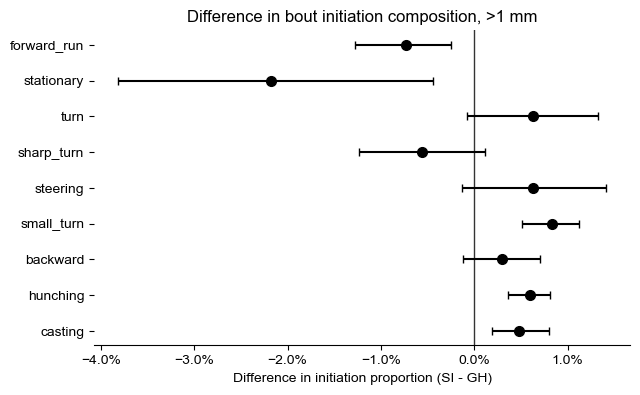

,behaviour,difference_si_minus_gh,ci_low,ci_high,n_GH,n_SI
0,forward_run,-0.007328,-0.012727,-0.002447,10,10
1,stationary,-0.021798,-0.038130,-0.004435,10,10
2,turn,0.006303,-0.000789,0.013264,10,10
3,sharp_turn,-0.005616,-0.012400,0.001141,10,10
4,steering,0.006348,-0.001358,0.014086,10,10
5,small_turn,0.008311,0.005112,0.011182,10,10
6,backward,0.002958,-0.001246,0.007046,10,10
7,hunching,0.006000,0.003579,0.008145,10,10
8,casting,0.004824,0.001865,0.008053,10,10


In [43]:
# Difference plot: SI - GH bout initiation proportion, digging removed

import matplotlib.ticker as mtick

# this cell expects bout_counts and behaviour_order from the horizontal plot cell above
comparison_conditions = [c for c in ["GH", "SI"] if c in bout_counts["condition"].unique()]

if comparison_conditions != ["GH", "SI"]:
    raise ValueError("This difference plot expects both GH and SI in bout_counts.")

rng = np.random.default_rng(1)
n_boot = 5000

diff_rows = []
for behaviour in behaviour_order:
    gh = bout_counts.loc[
        (bout_counts["condition"] == "GH") & (bout_counts["behaviour"] == behaviour),
        "bout_proportion",
    ].dropna().to_numpy()
    si = bout_counts.loc[
        (bout_counts["condition"] == "SI") & (bout_counts["behaviour"] == behaviour),
        "bout_proportion",
    ].dropna().to_numpy()

    observed_diff = si.mean() - gh.mean()
    boot_diffs = []
    for _ in range(n_boot):
        gh_sample = rng.choice(gh, size=len(gh), replace=True)
        si_sample = rng.choice(si, size=len(si), replace=True)
        boot_diffs.append(si_sample.mean() - gh_sample.mean())

    ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
    diff_rows.append({
        "behaviour": behaviour,
        "difference_si_minus_gh": observed_diff,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "n_GH": len(gh),
        "n_SI": len(si),
    })

diff_table = pd.DataFrame(diff_rows)

fig, ax = plt.subplots(figsize=(6.5, max(3.5, 0.45 * len(behaviour_order))))
y = np.arange(len(diff_table))
xerr = [
    diff_table["difference_si_minus_gh"] - diff_table["ci_low"],
    diff_table["ci_high"] - diff_table["difference_si_minus_gh"],
]

ax.axvline(0, color="black", lw=1, alpha=0.8)
ax.errorbar(
    diff_table["difference_si_minus_gh"],
    y,
    xerr=xerr,
    fmt="o",
    markersize=7,
    capsize=3,
    color="black",
    lw=1.5,
)

ax.set_yticks(y)
ax.set_yticklabels(diff_table["behaviour"])
ax.invert_yaxis()
ax.set_xlabel("Difference in initiation proportion (SI - GH)")
ax.set_ylabel("")
ax.set_title("Difference in bout initiation composition, >1 mm")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.show()

display(diff_table)
